In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  , GradientBoostingRegressor
from sklearn.metrics import (
        confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score,classification_report,
        mean_absolute_error,mean_squared_error,r2_score
    )
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [43]:
df = pd.read_csv('D:\Fci 2025-2026\Software Development\Elxair_Project\Ai_Features\Model\elxair_transactions_dataset_50000_renamed.csv')
df.head()

,TransactionID,PurchaseDate,PurchaseYear,PurchaseMonth,CustomerID,CustomerGovernorate,ProductID,ProductName,ProductBrand,ScentCategory,...,QuantityPurchased,IsPromotionApplied,DiscountPercent,DiscountedUnitPrice_EGP,TotalSaleAmount_EGP,CostToPriceRatio,TotalCostAmount_EGP,NetProfitAmount_EGP,PaymentStatus,CustomerRating
0,1,2023-01-01,2023,1,437,Assiut,17,Velour 17,Nile Essence,Musk,...,1,0,0.0,130.0,130.0,0.360,46.81,83.19,Paid,4.0
1,2,2023-01-01,2023,1,3659,Cairo,22,Elxair 22,Lumière Paris-Style,Oriental,...,4,0,0.0,50.0,200.0,0.381,76.21,123.79,Paid,5.0
2,3,2023-01-01,2023,1,3223,Cairo,38,Rosewood 38,Aurum Scents,Floral,...,4,0,0.0,130.0,520.0,0.357,185.44,334.56,Paid,NaN
3,4,2023-01-01,2023,1,214,Port Said,29,Rosewood 29,Desert Oud,Oriental,...,1,0,0.0,100.0,100.0,0.372,37.24,62.76,Refunded,NaN
4,5,2023-01-01,2023,1,658,Minya,38,Rosewood 38,Aurum Scents,Floral,...,1,1,25.0,22.5,22.5,0.441,13.22,9.28,Paid,NaN


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            50000 non-null  int64  
 1   PurchaseDate             50000 non-null  object 
 2   PurchaseYear             50000 non-null  int64  
 3   PurchaseMonth            50000 non-null  int64  
 4   CustomerID               50000 non-null  int64  
 5   CustomerGovernorate      50000 non-null  object 
 6   ProductID                50000 non-null  int64  
 7   ProductName              50000 non-null  object 
 8   ProductBrand             50000 non-null  object 
 9   ScentCategory            50000 non-null  object 
 10  TargetGender             50000 non-null  object 
 11  RecommendedSeason        50000 non-null  object 
 12  BottleSize               50000 non-null  object 
 13  OriginalUnitPrice_EGP    50000 non-null  int64  
 14  QuantityPurchased     

In [45]:
df.describe(include="all")

,TransactionID,PurchaseDate,PurchaseYear,PurchaseMonth,CustomerID,CustomerGovernorate,ProductID,ProductName,ProductBrand,ScentCategory,...,QuantityPurchased,IsPromotionApplied,DiscountPercent,DiscountedUnitPrice_EGP,TotalSaleAmount_EGP,CostToPriceRatio,TotalCostAmount_EGP,NetProfitAmount_EGP,PaymentStatus,CustomerRating
count,50000.000000,50000,50000.000000,50000.000000,50000.00000,50000,50000.000000,50000,50000,50000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,12548.000000
unique,NaN,1096,NaN,NaN,NaN,18,NaN,45,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,2024-12-16,NaN,NaN,NaN,Zagazig,NaN,Lumière 30,Aurum Scents,Fruity,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Paid,NaN
freq,NaN,79,NaN,NaN,NaN,2832,NaN,1176,10278,11172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44991,NaN
mean,25000.500000,NaN,2023.997380,6.646380,1972.84524,NaN,23.093800,NaN,NaN,NaN,...,1.433880,0.226840,4.531850,149.794243,215.383011,0.399873,90.259862,125.123149,NaN,4.172697
std,14433.901067,NaN,0.815271,3.584259,1158.88294,NaN,12.990243,NaN,NaN,NaN,...,0.749052,0.418792,8.809286,154.143522,275.586208,0.028819,115.202313,162.546584,NaN,0.702996
min,1.000000,NaN,2023.000000,1.000000,1.00000,NaN,1.000000,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,21.000000,21.000000,0.350000,10.500000,7.700000,NaN,2.000000
25%,12500.750000,NaN,2023.000000,3.000000,968.00000,NaN,12.000000,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,41.550000,50.000000,0.375000,20.950000,29.900000,NaN,4.000000
50%,25000.500000,NaN,2024.000000,7.000000,1945.00000,NaN,23.000000,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,100.000000,100.000000,0.400000,43.795000,61.730000,NaN,4.000000
75%,37500.250000,NaN,2025.000000,10.000000,2990.00000,NaN,34.000000,NaN,NaN,NaN,...,2.000000,0.000000,0.000000,223.200000,300.000000,0.425000,116.422500,168.922500,NaN,5.000000


In [46]:
df.dtypes

TransactionID                int64
PurchaseDate                object
PurchaseYear                 int64
PurchaseMonth                int64
CustomerID                   int64
CustomerGovernorate         object
ProductID                    int64
ProductName                 object
ProductBrand                object
ScentCategory               object
TargetGender                object
RecommendedSeason           object
BottleSize                  object
OriginalUnitPrice_EGP        int64
QuantityPurchased            int64
IsPromotionApplied           int64
DiscountPercent            float64
DiscountedUnitPrice_EGP    float64
TotalSaleAmount_EGP        float64
CostToPriceRatio           float64
TotalCostAmount_EGP        float64
NetProfitAmount_EGP        float64
PaymentStatus               object
CustomerRating             float64
dtype: object

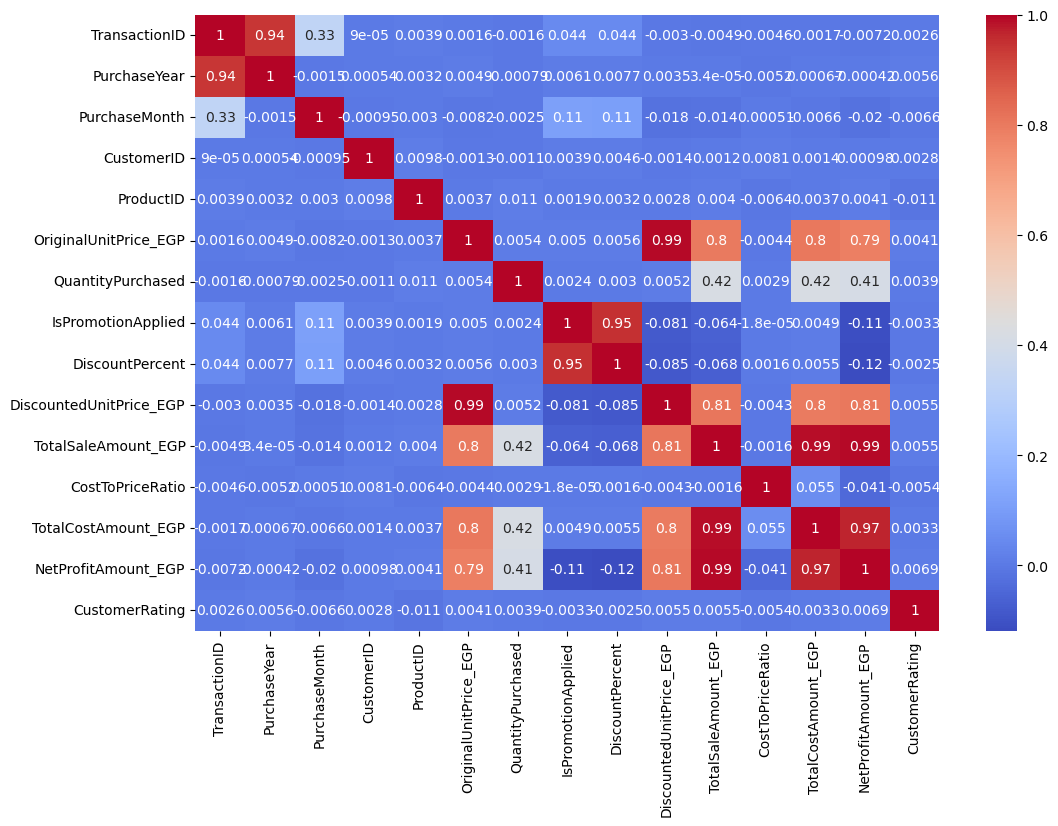

In [47]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

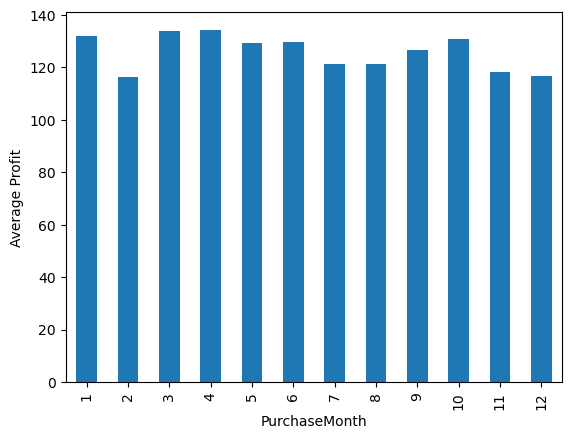

In [48]:
df.groupby("PurchaseMonth")["NetProfitAmount_EGP"].mean().plot.bar()

plt.ylabel("Average Profit")
plt.show()



In [49]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

CustomerRating    37452
dtype: int64

In [50]:
print(df.duplicated().sum())

0


In [51]:
df.drop(columns=[ 'PurchaseDate'  ,  'CustomerID' , 'CustomerGovernorate'  , 'ProductName' , 'ProductBrand' , 'PaymentStatus' , 'CustomerRating' , 'CostToPriceRatio' ] , axis=1 , inplace=True)
df.head()

,TransactionID,PurchaseYear,PurchaseMonth,ProductID,ScentCategory,TargetGender,RecommendedSeason,BottleSize,OriginalUnitPrice_EGP,QuantityPurchased,IsPromotionApplied,DiscountPercent,DiscountedUnitPrice_EGP,TotalSaleAmount_EGP,TotalCostAmount_EGP,NetProfitAmount_EGP
0,1,2023,1,17,Musk,Unisex,AllSeasons,15ml,130,1,0,0.0,130.0,130.0,46.81,83.19
1,2,2023,1,22,Oriental,Unisex,Winter,5ml,50,4,0,0.0,50.0,200.0,76.21,123.79
2,3,2023,1,38,Floral,Female,AllSeasons,15ml,130,4,0,0.0,130.0,520.0,185.44,334.56
3,4,2023,1,29,Oriental,Male,Summer,10ml,100,1,0,0.0,100.0,100.0,37.24,62.76
4,5,2023,1,38,Floral,Female,AllSeasons,3ml,30,1,1,25.0,22.5,22.5,13.22,9.28


In [52]:
def sold_in_season(row):
    if row["RecommendedSeason"] == "AllSeasons":
        return 1

    elif row["RecommendedSeason"] == "Summer":
        return 1 if row["PurchaseMonth"] in [4 ,5, 6, 7, 8, 9 , 10] else 0

    elif row["RecommendedSeason"] == "Winter":
        return 1 if row["PurchaseMonth"] in [ 11, 12, 1, 2, 3] else 0

    return 0


df["SoldInSeason"] = df.apply(sold_in_season, axis=1)
df.head()

,TransactionID,PurchaseYear,PurchaseMonth,ProductID,ScentCategory,TargetGender,RecommendedSeason,BottleSize,OriginalUnitPrice_EGP,QuantityPurchased,IsPromotionApplied,DiscountPercent,DiscountedUnitPrice_EGP,TotalSaleAmount_EGP,TotalCostAmount_EGP,NetProfitAmount_EGP,SoldInSeason
0,1,2023,1,17,Musk,Unisex,AllSeasons,15ml,130,1,0,0.0,130.0,130.0,46.81,83.19,1
1,2,2023,1,22,Oriental,Unisex,Winter,5ml,50,4,0,0.0,50.0,200.0,76.21,123.79,1
2,3,2023,1,38,Floral,Female,AllSeasons,15ml,130,4,0,0.0,130.0,520.0,185.44,334.56,1
3,4,2023,1,29,Oriental,Male,Summer,10ml,100,1,0,0.0,100.0,100.0,37.24,62.76,0
4,5,2023,1,38,Floral,Female,AllSeasons,3ml,30,1,1,25.0,22.5,22.5,13.22,9.28,1


In [53]:
month_map = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["PurchaseMonth"] = df["PurchaseMonth"].astype(int).map(month_map)
df.head()

,TransactionID,PurchaseYear,PurchaseMonth,ProductID,ScentCategory,TargetGender,RecommendedSeason,BottleSize,OriginalUnitPrice_EGP,QuantityPurchased,IsPromotionApplied,DiscountPercent,DiscountedUnitPrice_EGP,TotalSaleAmount_EGP,TotalCostAmount_EGP,NetProfitAmount_EGP,SoldInSeason
0,1,2023,January,17,Musk,Unisex,AllSeasons,15ml,130,1,0,0.0,130.0,130.0,46.81,83.19,1
1,2,2023,January,22,Oriental,Unisex,Winter,5ml,50,4,0,0.0,50.0,200.0,76.21,123.79,1
2,3,2023,January,38,Floral,Female,AllSeasons,15ml,130,4,0,0.0,130.0,520.0,185.44,334.56,1
3,4,2023,January,29,Oriental,Male,Summer,10ml,100,1,0,0.0,100.0,100.0,37.24,62.76,0
4,5,2023,January,38,Floral,Female,AllSeasons,3ml,30,1,1,25.0,22.5,22.5,13.22,9.28,1


In [54]:
monthly_df = (
    df.groupby(
        [
            "PurchaseYear",
            "PurchaseMonth",
            "ProductID",
            "BottleSize"
        ]
    )
    .agg(
        Month=("PurchaseMonth" , "first"),
        Category=("ScentCategory", "first"),
        Gender=("TargetGender", "first"),
        Season=("RecommendedSeason", "first"),
        SoldInSeason=("SoldInSeason", "first"),

       TotalSales=("OriginalUnitPrice_EGP" , "sum"),
       TotalCost=("TotalCostAmount_EGP" ,"sum" ),

       NumberOfTransaction=("TransactionID" , "count"),

        
        AvgDiscount=("DiscountPercent", "mean"),
        TotalProfit=("NetProfitAmount_EGP", "sum")
    )
    .reset_index()
)


monthly_df.drop(columns=['PurchaseYear' , 'PurchaseMonth' , 'ProductID'] , axis=1 , inplace=True)
monthly_df.head()

,BottleSize,Month,Category,Gender,Season,SoldInSeason,TotalSales,TotalCost,NumberOfTransaction,AvgDiscount,TotalProfit
0,100ml,April,Oriental,Male,Summer,1,600,256.97,1,0.000000,343.03
1,10ml,April,Oriental,Male,Summer,1,300,157.74,3,4.200000,217.06
2,15ml,April,Oriental,Male,Summer,1,780,296.29,6,7.833333,422.61
3,30ml,April,Oriental,Male,Summer,1,600,367.49,2,0.000000,532.51
4,3ml,April,Oriental,Male,Summer,1,240,106.12,8,0.000000,163.88


In [55]:
num_cols = ['NumberOfTransaction','AvgDiscount', 'TotalCost' , 'TotalProfit'   ]
def remove_outliers(monthly_df, columns):
    for col in columns:
        Q1 = monthly_df[col].quantile(0.25)
        Q3 = monthly_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        monthly_df = monthly_df[(monthly_df[col] >= lower_bound) & (monthly_df[col] <= upper_bound)]
    return monthly_df

monthly_df = remove_outliers(monthly_df, num_cols)
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9524 entries, 0 to 10771
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BottleSize           9524 non-null   object 
 1   Month                9524 non-null   object 
 2   Category             9524 non-null   object 
 3   Gender               9524 non-null   object 
 4   Season               9524 non-null   object 
 5   SoldInSeason         9524 non-null   int64  
 6   TotalSales           9524 non-null   int64  
 7   TotalCost            9524 non-null   float64
 8   NumberOfTransaction  9524 non-null   int64  
 9   AvgDiscount          9524 non-null   float64
 10  TotalProfit          9524 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 892.9+ KB


In [56]:
monthly_df.isnull().sum()

BottleSize             0
Month                  0
Category               0
Gender                 0
Season                 0
SoldInSeason           0
TotalSales             0
TotalCost              0
NumberOfTransaction    0
AvgDiscount            0
TotalProfit            0
dtype: int64

In [57]:
X = monthly_df.drop(columns=["TotalProfit"])
y = monthly_df["TotalProfit"]

cat_cols = ["Month" ,"BottleSize", "Category", "Gender", "Season"]

num_cols = [
    "TotalSales",
    "NumberOfTransaction",
    "TotalCost",
    "AvgDiscount"
]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num" , StandardScaler() , num_cols),
        ("cat" , OneHotEncoder(handle_unknown="ignore") , cat_cols)
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("model" , RandomForestRegressor())
])

pipeline.fit(X_train, y_train)

print("Train R²:", pipeline.score(X_train, y_train))
print("Test R² :", pipeline.score(X_test, y_test))

Train R²: 0.99871758147806
Test R² : 0.9912345909472676


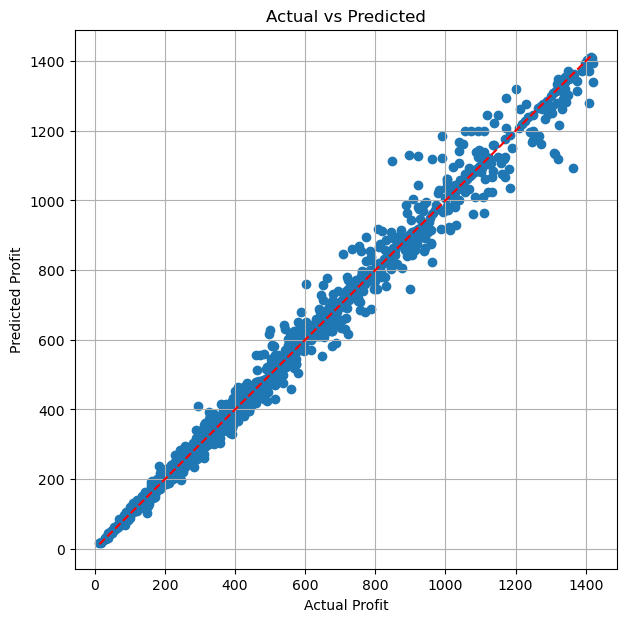

In [58]:
y_pred = pipeline.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [62]:
import joblib
joblib.dump(pipeline, "Random_Forest_Pipeline.pkl")

['Random_Forest_Pipeline.pkl']